In [1]:
import numpy as np
from qutip import *
from scipy.optimize import minimize

Optimization Result:
Final cost value: 7.369056506078432e-13


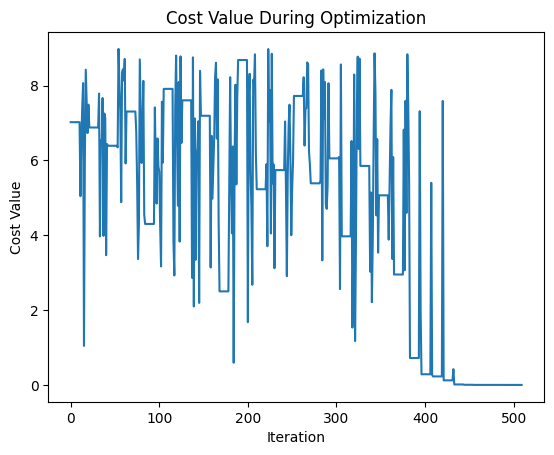

In [ ]:
costval= []
def cost(cutoff, a, eta):
    x = position(cutoff)
    aI = a * qeye(cutoff)  
    Hc = (x - aI) ** 2   # Cost Hamiltonian
    costH = (-1j * eta * Hc).expm()
    return costH

def mixer(cutoff, gamma):
    p = num(cutoff)
    Hm = p**2/2   # Mixer Hamiltonian
    mixerH = (-1j * gamma * Hm).expm()
    return mixerH

# Define the CV-QAOA function
def cvQAOA(params, cutoff, a, s, p):
    gamma_list = params[:p]
    eta_list = params[p:]

    state = basis(cutoff,0)
    state_sq = squeeze(cutoff, -s)
    state  = state_sq*state

    # Apply QAOA layers
    for i in range(p):
        gamma = gamma_list[i]
        eta = eta_list[i]
        costH = cost(cutoff, a, eta)
        state = costH * state  # Apply cost gate

        mixH = mixer(cutoff, gamma)
        state = mixH * state  # Apply mixer gate

    x = position(cutoff)
    expval = abs(expect(x, state))
    cost_val = (expval - a) ** 2
    costval.append(cost_val)

    return (cost_val)

cutoff = 32
a = 3.0  # minima point
s = 1.0
p = 5

def optimizer_function(params):
    return cvQAOA(params, cutoff, a, s, p)

result = minimize(
    optimizer_function,
    [6.25]*10,  # Initial guesses for gamma and eta
    method="SLSQP",
    tol=1e-9,
    options={'maxiter': 2000}
)

print("Optimization Result:")
print("Final cost value:", result.fun)

import matplotlib.pyplot as plt

plt.plot(costval)
plt.xlabel("Iteration")
plt.ylabel("Cost Value")
plt.title("Cost Value During Optimization")
plt.show()

In [6]:
def result_final(params, cutoff, a, s, p):
    gamma_list = params[:p]
    eta_list = params[p:]

    state = basis(cutoff,0)
    state_sq = squeeze(cutoff, -s)
    state  = state_sq*state

    # Apply QAOA layers
    for i in range(p):
        gamma = gamma_list[i]
        eta = eta_list[i]

        costH = cost(cutoff, a, eta)
        state = costH * state

        mixH = mixer(cutoff, gamma)
        state = mixH * state

    x = position(cutoff)
    expval = abs(expect(x, state))
    cost_val = (expval - a) ** 2
    costval.append(cost_val)

    return expval

In [7]:
a_opt = result_final(result.x, cutoff, a, s, p)
print(f'Minima is at {a_opt}')

Minima is at 2.9999991415679115
